# Validation 05 — Floating Windows & Gantt Plot (Cell 13)
Verifies 5 s bar width (not 1 s), 80% overlap, and Gantt stacking.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


In [2]:
def load_wav(path):
    fs,data=wavfile.read(path)
    if data.ndim>1: data=data[:,0]
    if   data.dtype==np.int16:  sig=data.astype(np.float64)/32768.0
    elif data.dtype==np.int32:  sig=data.astype(np.float64)/2147483648.0
    else:                       sig=data.astype(np.float64)
    return fs,sig,len(sig)/fs

def detect_onset(signal,fs):
    hop=int(ENERGY_WINDOW_S*fs); n=len(signal)//hop
    rms=np.array([np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2)) for i in range(n)])
    nf=np.mean(rms[:max(1,int(NOISE_DURATION_S/ENERGY_WINDOW_S))])
    ab=np.where(rms>ONSET_THRESHOLD*nf)[0]
    of=int(ab[0]) if len(ab) else int(np.argmax(rms))
    return of*hop, of*ENERGY_WINDOW_S, np.arange(n)*ENERGY_WINDOW_S, rms, nf

def make_windows(signal,fs):
    wl=int(WINDOW_DURATION_S*fs); sl=int(WINDOW_STEP_S*fs)
    n=max(0,(len(signal)-wl)//sl+1)
    return [signal[i*sl:i*sl+wl] for i in range(n)], np.arange(n)*WINDOW_STEP_S

def design_filter(ftype,order,lo,hi,fs):
    nyq=fs/2.; Wn=[lo/nyq,hi/nyq]
    if ftype=='Butterworth':  return butter(order,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev I':  return cheby1(order,CHEBY1_RIPPLE_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev II': return cheby2(order,CHEBY2_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Elliptical':   return ellip(order,ELLIP_RIPPLE_DB,ELLIP_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Bessel':       return bessel(order,Wn,btype='bandpass',output='sos',norm='phase')

all_wavs = sorted(set(DATA_DIR.rglob("*.wav"))|set(DATA_DIR.rglob("*.WAV")))
def skey(p):
    s=Path(p).stem.split('_')[-1]
    return SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99
all_wavs = sorted(all_wavs,key=skey)
EXAMPLE_WAV = all_wavs[0] if all_wavs else None
print(f"WAV files found: {len(all_wavs)}")
if EXAMPLE_WAV: print(f"Using: {EXAMPLE_WAV.name}")


WAV files found: 1568
Using: G80_8_3_0_AccAxial4507.wav


  [PASS]  At least 1 window extracted  → 64 windows
  [PASS]  Window duration = 5 s
  [PASS]  Window step = 1 s
  [PASS]  Overlap = 80%  → 80.0%
  [PASS]  Each window has correct length  → 240000 samples each
  [PASS]  Window starts monotone increasing
  [PASS]  Gantt stack rows = 5 (5 s / 1 s)  → n_stack=5
  [PASS]  Bar width = WINDOW_DURATION_S (5 s), NOT step (1 s)  → Gantt bars are 5 s wide — mentor's original concern resolved
  [PASS]  No window overflows useful signal
  [INFO]  Windows: 64
  [INFO]  Overlap: 80%
  [INFO]  Gantt rows: 5


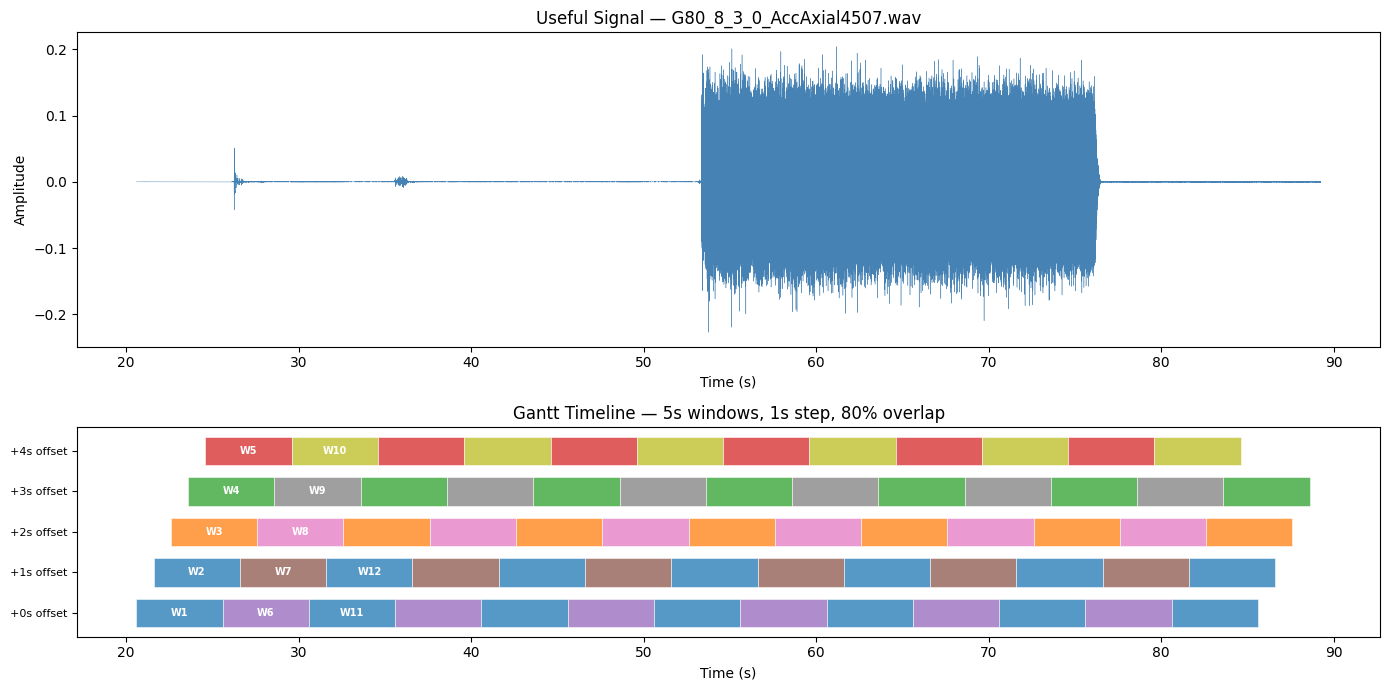


  PASS: 9/9  |  FAIL: 0/9
  Score: 100%


In [3]:
if not EXAMPLE_WAV: raise SystemExit
fs,signal,duration = load_wav(EXAMPLE_WAV)
_,onset_time,_,_,_ = detect_onset(signal,fs)
useful_start_time  = onset_time+ONSET_OFFSET_S
useful_signal      = signal[int(useful_start_time*fs):]
windows,window_starts = make_windows(useful_signal,fs)
win_len   = int(WINDOW_DURATION_S*fs)
overlap   = (1-WINDOW_STEP_S/WINDOW_DURATION_S)*100
n_stack   = int(WINDOW_DURATION_S/WINDOW_STEP_S)

check("At least 1 window extracted",       len(windows)>0,            f"{len(windows)} windows")
check("Window duration = 5 s",             WINDOW_DURATION_S==5.0)
check("Window step = 1 s",                 WINDOW_STEP_S==1.0)
check("Overlap = 80%",                     abs(overlap-80.0)<0.01,    f"{overlap:.1f}%")
check("Each window has correct length",    all(len(w)==win_len for w in windows), f"{win_len} samples each")
check("Window starts monotone increasing", np.all(np.diff(window_starts)>0) if len(window_starts)>1 else True)
check("Gantt stack rows = 5 (5 s / 1 s)", n_stack==5,                f"n_stack={n_stack}")
check("Bar width = WINDOW_DURATION_S (5 s), NOT step (1 s)",
      WINDOW_DURATION_S==5.0 and WINDOW_STEP_S==1.0,
      "Gantt bars are 5 s wide — mentor's original concern resolved")
check("No window overflows useful signal",
      all((i*int(WINDOW_STEP_S*fs)+win_len)<=len(useful_signal) for i in range(len(windows))))

info("Windows", len(windows)); info("Overlap", f"{overlap:.0f}%"); info("Gantt rows", n_stack)

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),gridspec_kw={'height_ratios':[3,2]})
t_abs=np.arange(len(useful_signal))/fs+useful_start_time
ax1.plot(t_abs,useful_signal,lw=0.3,color='steelblue')
ax1.set_title(f'Useful Signal — {EXAMPLE_WAV.name}'); ax1.set_ylabel('Amplitude'); ax1.set_xlabel('Time (s)')
colors=plt.cm.tab10(np.linspace(0,0.8,min(len(windows),10)))
for i,s in enumerate(window_starts):
    abs_s=useful_start_time+s
    y=i%n_stack
    ax2.barh(y,WINDOW_DURATION_S,left=abs_s,height=0.7,color=colors[i%len(colors)],alpha=0.75,edgecolor='white',lw=0.5)
    if i<12: ax2.text(abs_s+WINDOW_DURATION_S/2,y,f'W{i+1}',ha='center',va='center',fontsize=7,color='white',fontweight='bold')
ax2.set_yticks(range(n_stack)); ax2.set_yticklabels([f'+{j}s offset' for j in range(n_stack)],fontsize=8)
ax2.set_xlabel('Time (s)'); ax2.set_xlim(ax1.get_xlim())
ax2.set_title(f'Gantt Timeline — {WINDOW_DURATION_S:.0f}s windows, {WINDOW_STEP_S:.0f}s step, {overlap:.0f}% overlap')
plt.tight_layout(); plt.show(); plt.close('all')
summary()
